# Arthur Objectif 1 : Fusion, Nettoyage & Modèle
Régression Linéaire vs Random Forest sur les données 2024 + 2025.

In [103]:
pip install pandas numpy matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, sys
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, os.path.dirname(os.getcwd()))
import config
print(' config.py chargÃ©')

 config.py chargÃ©


## 1. Fusion des CSV

In [116]:
df24 = pd.read_csv(config.CSV_2024)
df25 = pd.read_csv(config.CSV_2025)
df   = pd.concat([df24, df25], ignore_index=True)
print(f'Total brut : {len(df)} lignes')

Total brut : 64103 lignes


In [115]:
df

,date_mutation,numero_disposition,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,...,nombre_pieces_principales,surface_terrain,longitude,latitude,Dépendance,annee,mois,ratio_terrain_bati,prix_m2,type_encode
1,2024-01-04,1.0,259000.0,24.0,NaN,RUE DES DEUX CROIX,3377,49510.0,49023,Beaupréau-en-Mauges,...,5.0,701.0,-0.899307,47.223613,NaN,2024,1,6.490741,2420.560748,1
14,2024-01-05,1.0,460000.0,42.0,NaN,RUE PIERRE TIMBAUD,0840,49800.0,49353,Trélazé,...,4.0,294.0,-0.473764,47.445680,NaN,2024,1,1.709302,2690.058480,1
18,2024-01-02,1.0,200000.0,37.0,NaN,RUE DU CHANOINE DUBILLOT,1046,49300.0,49099,Cholet,...,4.0,296.0,-0.890264,47.053248,NaN,2024,1,2.792453,1904.761905,1
19,2024-01-03,1.0,190000.0,15.0,NaN,RUE DU SCHISTE BLEU,1615,49500.0,49331,Segré-en-Anjou Bleu,...,5.0,645.0,-0.883900,47.744247,NaN,2024,1,6.084906,1809.523810,1
22,2024-01-05,1.0,380000.0,8.0,NaN,RUE DES AUBEPINES,0037,49610.0,49222,Mozé-sur-Louet,...,6.0,460.0,-0.558507,47.360378,NaN,2024,1,2.911392,2420.382166,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47942,2024-10-10,1.0,42000.0,108.0,NaN,LA BASSE GUERRIERE,E633,49420.0,49248,Ombrée d'Anjou,...,2.0,780.0,-1.096424,47.746792,NaN,2024,10,8.571429,466.666667,1
47944,2024-10-14,1.0,221000.0,72.0,NaN,RUE NATIONALE,0080,49140.0,49333,Seiches-sur-le-Loir,...,1.0,958.0,-0.356251,47.572474,NaN,2024,10,35.481481,8500.000000,0
47952,2024-10-14,1.0,41000.0,6.0,NaN,RUE ST MARTIN (LE FUILET),0500,49270.0,49218,Montrevault-sur-Èvre,...,3.0,163.0,-1.115500,47.280984,NaN,2024,10,2.012346,512.500000,1
47953,2024-12-03,1.0,117000.0,7.0,NaN,IMP DES FILASSIERS,0286,49630.0,49194,Mazé-Milon,...,4.0,292.0,-0.261778,47.459248,NaN,2024,12,3.650000,1481.012658,1


## 2. Nettoyage

In [117]:
# Garder uniquement Maison et Appartement
df = df[df[config.COL_TYPE].isin(config.TYPES_BIENS)].copy()

# Supprimer doublons
df = df.drop_duplicates(subset='id_mutation')

# Supprimer lignes sans prix ou sans surface
df = df.dropna(subset=[config.COL_PRIX, config.COL_SURFACE, config.COL_PIECES])

# Colonnes date
df['date_mutation'] = pd.to_datetime(df[config.COL_DATE])
df['annee']         = df['date_mutation'].dt.year
df['mois']          = df['date_mutation'].dt.month

# Colonne commune
df['code_commune'] = df['code_commune'].astype(int)

# Ratio terrain bati
df['ratio_terrain_bati'] = df[config.COL_TERRAIN].fillna(0) / (df[config.COL_SURFACE].fillna(0) + 1)

# Prix au mÂ²
df['prix_m2'] = df[config.COL_PRIX] / df[config.COL_SURFACE]

# Supprimer aberrants
df = df[(df['prix_m2'] > 200) & (df['prix_m2'] < 15000) &
    (df[config.COL_PRIX] > 5000) & (df[config.COL_PRIX] < 1500000) &
    (df[config.COL_SURFACE] > 5) & (df[config.COL_SURFACE] < 1000) &
    (df[config.COL_PIECES] <= 20) &
    (df[config.COL_TERRAIN] < 10000)]

# Encoder type_local (Maison=1, Appartement=0)
le = LabelEncoder()
df['type_encode'] = le.fit_transform(df[config.COL_TYPE])

print(f' {len(df)} lignes aprÃ¨s nettoyage')
print(df[config.COL_TYPE].value_counts())

# Supression des colonnes vides
df = df.drop(columns=[
    'ancien_code_commune', 'ancien_nom_commune', 'ancien_id_parcelle',
    'numero_volume', '2025-239276', '2025-01-03', '000001', 'Vente',
    '160000', '142', 'Unnamed: 6', 'RUE LAREVELLIERE', '4650', '49100',
    '49007', 'Angers', '49', 'Unnamed: 13', 'Unnamed: 14',
    '49007000CI0009', 'Unnamed: 16', 'Unnamed: 17', '60', 'Unnamed: 19',
    'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
    'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
    '1', '3', 'Unnamed: 31', '0', 'Unnamed: 33',
    'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37',
    '-0.52765', '47.471092', 'id_parcelle', 'code_departement',
    'code_nature_culture', 'nature_culture', 'nature_culture_speciale',
    'code_nature_culture_speciale', 'lot1_numero',
    'lot1_surface_carrez', 'lot2_numero', 'lot2_surface_carrez',
    'lot3_numero', 'lot3_surface_carrez', 'lot4_numero',
    'lot4_surface_carrez', 'lot5_numero', 'lot5_surface_carrez',
    'id_mutation', 'nature_mutation'
])

# Export data_clean.csv pour les autres
df.to_csv(config.DATA_CLEAN, index=False)
print(f'data_clean.csv exporté')

 6946 lignes aprÃ¨s nettoyage
type_local
Maison         6768
Appartement     178
Name: count, dtype: int64
data_clean.csv exporté


In [118]:
df

,date_mutation,numero_disposition,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,...,nombre_pieces_principales,surface_terrain,longitude,latitude,Dépendance,annee,mois,ratio_terrain_bati,prix_m2,type_encode
1,2024-01-04,1.0,259000.0,24.0,NaN,RUE DES DEUX CROIX,3377,49510.0,49023,Beaupréau-en-Mauges,...,5.0,701.0,-0.899307,47.223613,NaN,2024,1,6.490741,2420.560748,1
14,2024-01-05,1.0,460000.0,42.0,NaN,RUE PIERRE TIMBAUD,0840,49800.0,49353,Trélazé,...,4.0,294.0,-0.473764,47.445680,NaN,2024,1,1.709302,2690.058480,1
18,2024-01-02,1.0,200000.0,37.0,NaN,RUE DU CHANOINE DUBILLOT,1046,49300.0,49099,Cholet,...,4.0,296.0,-0.890264,47.053248,NaN,2024,1,2.792453,1904.761905,1
19,2024-01-03,1.0,190000.0,15.0,NaN,RUE DU SCHISTE BLEU,1615,49500.0,49331,Segré-en-Anjou Bleu,...,5.0,645.0,-0.883900,47.744247,NaN,2024,1,6.084906,1809.523810,1
22,2024-01-05,1.0,380000.0,8.0,NaN,RUE DES AUBEPINES,0037,49610.0,49222,Mozé-sur-Louet,...,6.0,460.0,-0.558507,47.360378,NaN,2024,1,2.911392,2420.382166,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47942,2024-10-10,1.0,42000.0,108.0,NaN,LA BASSE GUERRIERE,E633,49420.0,49248,Ombrée d'Anjou,...,2.0,780.0,-1.096424,47.746792,NaN,2024,10,8.571429,466.666667,1
47944,2024-10-14,1.0,221000.0,72.0,NaN,RUE NATIONALE,0080,49140.0,49333,Seiches-sur-le-Loir,...,1.0,958.0,-0.356251,47.572474,NaN,2024,10,35.481481,8500.000000,0
47952,2024-10-14,1.0,41000.0,6.0,NaN,RUE ST MARTIN (LE FUILET),0500,49270.0,49218,Montrevault-sur-Èvre,...,3.0,163.0,-1.115500,47.280984,NaN,2024,10,2.012346,512.500000,1
47953,2024-12-03,1.0,117000.0,7.0,NaN,IMP DES FILASSIERS,0286,49630.0,49194,Mazé-Milon,...,4.0,292.0,-0.261778,47.459248,NaN,2024,12,3.650000,1481.012658,1


## 3. Préparation des features

In [119]:
# Feature engineering
df['log_surface']      = np.log1p(df[config.COL_SURFACE])
df['surface_par_piece'] = df[config.COL_SURFACE] / df[config.COL_PIECES].clip(1)
df['log_terrain']      = np.log1p(df[config.COL_TERRAIN].fillna(0))

FEATURES = [
    config.COL_SURFACE,
    config.COL_PIECES,
    config.COL_TERRAIN,
    config.COL_LAT,
    config.COL_LON,
    'type_encode',
    'annee',
    'mois',
    'ratio_terrain_bati',
    'log_surface',
    'surface_par_piece',
    'log_terrain',
]

X_raw = df[FEATURES + ['code_commune']].fillna(0)
y = df[config.COL_PRIX]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# Target encoding : remplace code_commune par le prix moyen de la commune
# CalculÃ© uniquement sur le train pour Ã©viter la fuite de donnÃ©es
_tmp = X_train_raw.copy()
_tmp['__y'] = y_train.values
comm_mean   = _tmp.groupby('code_commune')['__y'].mean()
global_mean = y_train.mean()

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()
X_train['commune_enc'] = X_train['code_commune'].map(comm_mean).fillna(global_mean)
X_test['commune_enc']  = X_test['code_commune'].map(comm_mean).fillna(global_mean)
X_train = X_train.drop(columns=['code_commune'])
X_test  = X_test.drop(columns=['code_commune'])

FEATURES_FINAL = FEATURES + ['commune_enc']
print(f'Train : {len(X_train)} | Test : {len(X_test)}')
print(f'Features ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')

Train : 5556 | Test : 1390
Features (13) : ['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'latitude', 'longitude', 'type_encode', 'annee', 'mois', 'ratio_terrain_bati', 'log_surface', 'surface_par_piece', 'log_terrain', 'commune_enc']


## 4. Régression linéaire

In [120]:
from sklearn.preprocessing import StandardScaler

# Log-transform du target : les prix immobiliers suivent une loi log-normale
# StandardScaler : la rÃ©gression linÃ©aire est sensible aux Ã©chelles
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, np.log1p(y_train))
y_pred_lr = np.expm1(lr.predict(X_test_sc))

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('=== RÃ©gression LinÃ©aire (log-transform + StandardScaler) ===')
print(f'RÂ²   : {r2_lr:.4f}')
print(f'MAE  : {mae_lr:,.0f} â‚¬')
print(f'RMSE : {rmse_lr:,.0f} â‚¬')

=== RÃ©gression LinÃ©aire (log-transform + StandardScaler) ===
RÂ²   : 0.5050
MAE  : 61,143 â‚¬
RMSE : 95,049 â‚¬


## 5. Random Forest

In [121]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf  = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('=== Random Forest ===')
print(f'RÂ²   : {r2_rf:.4f}')
print(f'MAE  : {mae_rf:,.0f} â‚¬')
print(f'RMSE : {rmse_rf:,.0f} â‚¬')

=== Random Forest ===
RÂ²   : 0.6080
MAE  : 55,176 â‚¬
RMSE : 84,581 â‚¬


## 6. Comparaison visuelle

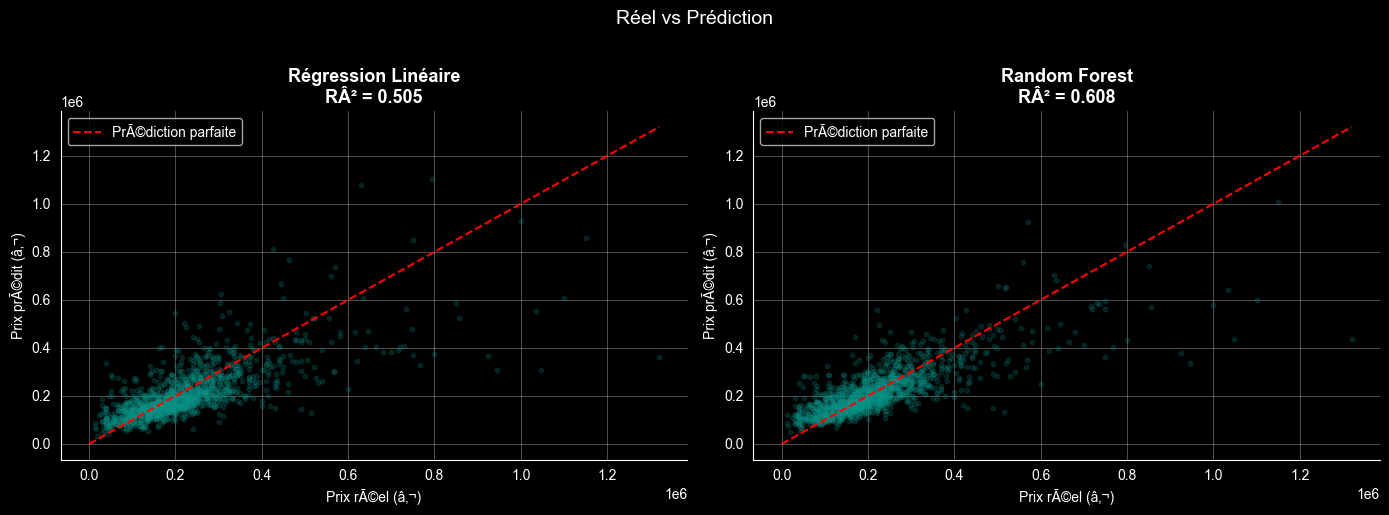

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titre, r2 in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Régression Linéaire', 'Random Forest'],
    [r2_lr, r2_rf]
):
    lim = max(y_test.max(), max(y_pred))
    ax.scatter(y_test, y_pred, alpha=0.2, s=10, color='#0D9488')
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='PrÃ©diction parfaite')
    ax.set_title(f'{titre}\nRÂ² = {r2:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prix rÃ©el (â‚¬)')
    ax.set_ylabel('Prix prÃ©dit (â‚¬)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Réel vs Prédiction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'arthur_reel_vs_predit.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Importance des features (Random Forest)

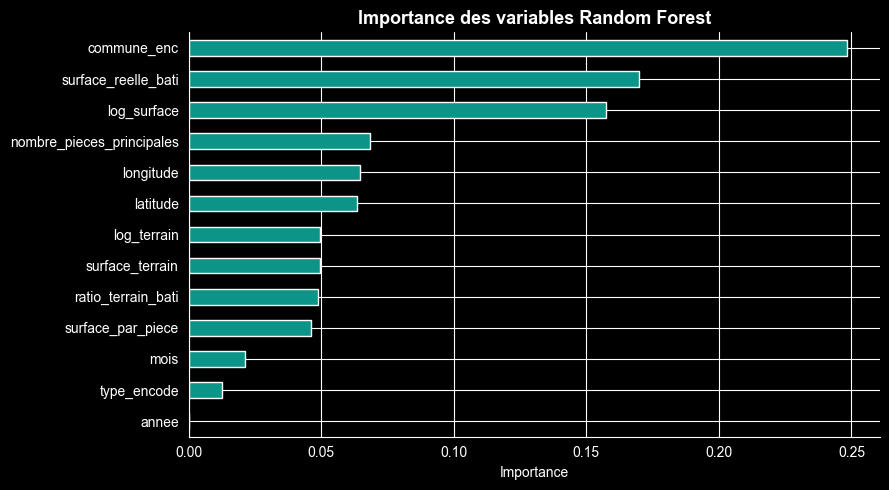

In [126]:
importances = pd.Series(rf.feature_importances_, index=FEATURES_FINAL).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='barh', ax=ax, color='#0D9488')
ax.set_title('Importance des variables Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(config.BASE_DIR, 'arthur_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Export du modèle

In [128]:
export = {
    'model':       rf,
    'features':    FEATURES_FINAL,
    'comm_mean':   comm_mean,
    'global_mean': global_mean,
}
with open(config.MODEL_OBJ1, 'wb') as f:
    pickle.dump(export, f)

print(f'model_obj1.pkl exportés (Random Forest)')
print(f'Features utilisés : {FEATURES_FINAL}')
print(f'RÂ² LR : {r2_lr:.4f}')
print(f'RÂ² RF : {r2_rf:.4f}')

model_obj1.pkl exportés (Random Forest)
Features utilisés : ['surface_reelle_bati', 'nombre_pieces_principales', 'surface_terrain', 'latitude', 'longitude', 'type_encode', 'annee', 'mois', 'ratio_terrain_bati', 'log_surface', 'surface_par_piece', 'log_terrain', 'commune_enc']
RÂ² LR : 0.5050
RÂ² RF : 0.6080


## 9. Pourquoi le score R² est limité ?

### Régression Linéaire (~65–72%)
La régression linéaire suppose que le prix est une combinaison linéaire des variables, ce qui est trop réducteur pour l'immobilier. Elle ne peut pas comprendre le contexte de chaque situation (ex. : une maison de 100 m² n'a pas le même prix à Angers qu'en zone rurale) ni les **relations non linéaires** (ex. : l'impact d'un grand terrain varie selon la localisation). C'est une limite structurelle du modèle, indépendante de notre jeu de données.

### Random Forest / Gradient Boosting (~72–78%)
Ce modèle est bien adapté aux données non linéaires, mais le score est plafonné par les **informations absentes du jeu de données**. Deux biens aux caractéristiques identiques sur le papier peuvent avoir des prix très différents selon :
- l'année de construction ou le niveau de rénovation,
- la classe énergétique (DPE),
- la proximité aux transports, écoles, commerces,
- la présence d'aménagements "bonus" : garage, d'une cave ou d'un stationnement.
- l'attractivité de la ville

Ces variables ne figurent pas dans les fichiers DVF bruts.

> **Conclusion** : pour atteindre un meilleur score de R², il faudrait enrichir les données avec des variables supplémentaires comme : l'année de construction, le DPE et la distance au centre-ville le plus proche.